<a href="https://colab.research.google.com/github/Geeta-Santhosh/Employee/blob/main/kaggle_churn_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv('/content/drive/MyDrive/Geeta-New-Drive/kaggle data set/Churn_Modelling.csv')
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
num, obj = 0,0
for cols in data.columns:
  if data[cols].dtype != 'O':
    num+=1
  else:
    obj+=1



print(f'There are {num} numarical and {obj} categorical columns')


There are 11 numarical and 3 categorical columns


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
data.shape

(10000, 14)

In [7]:
data['Exited'].unique()

array([1, 0])

In [8]:
#maping 0 and 1 to exited and stayed employees
data['Exited'] = data['Exited'].map({0 : 'Stay', 1 : 'Exited'})

In [9]:
#Exited and stayed in percentage
exited_proportion = data['Exited'].value_counts(normalize=True)*100
exited_proportion

,proportion
Exited,
Stay,79.63
Exited,20.37


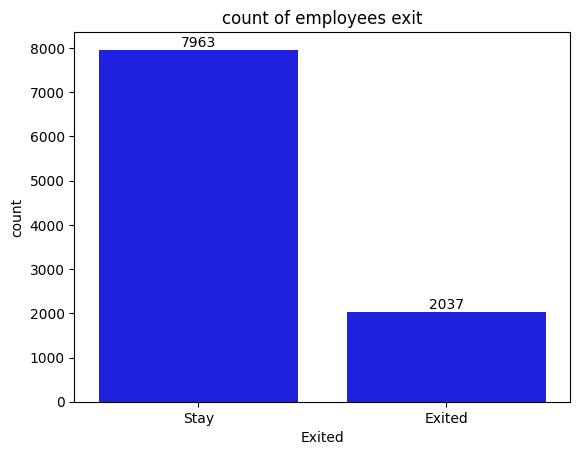

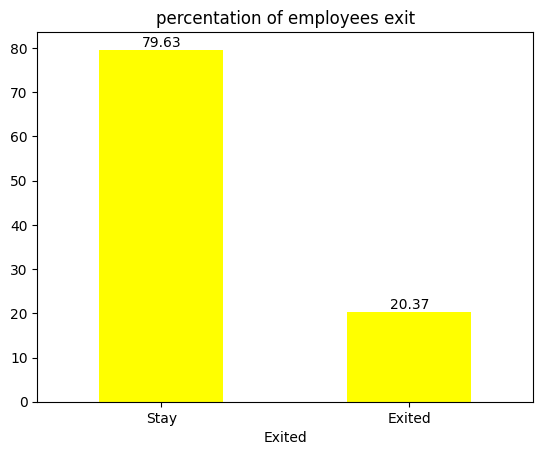

In [10]:
ax = sns.countplot(x=data['Exited'], order=data['Exited'].value_counts().index, color='blue')
ax.bar_label(ax.containers[0])
plt.title('count of employees exit')
plt.show()


ax = exited_proportion.plot.bar(color='yellow')
ax.bar_label(ax.containers[0])
plt.xticks(rotation=0)
plt.title('percentation of employees exit')
plt.show()

In [11]:
data['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [12]:
# Geographycally exited status in percentage
geography_exited = round(data.groupby('Geography')['Exited'].value_counts(normalize=True)*100,2).unstack()
geography_exited

Exited,Exited,Stay
Geography,,
France,16.15,83.85
Germany,32.44,67.56
Spain,16.67,83.33


min:  18
max:  92
q1:  32.0
q2:  37.0
q3:  44.0
Lower fence is:  14.0
upper fence is:  62.0


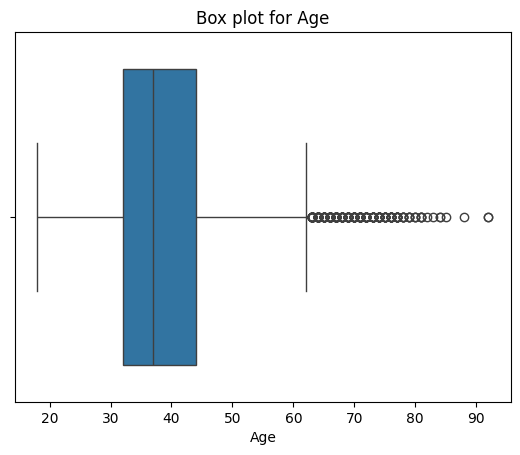

In [13]:
#Boxplot for Geographycal outliers

min = data['Age'].min()
max = data['Age'].max()
q1 = data['Age'].quantile(0.25)
q2 = data['Age'].quantile(0.5)
q3 = data['Age'].quantile(0.75)

print('min: ', min)
print('max: ', max)
print('q1: ', q1)
print('q2: ', q2)
print('q3: ', q3)

iqr = q3 - q1

lower_fence = q1 - 1.5*(iqr)
upper_fence = q3 + 1.5*(iqr)

print('Lower fence is: ', lower_fence)
print('upper fence is: ', upper_fence)

sns.boxplot(x=data['Age'])
plt.title('Box plot for Age')
plt.show()

In [14]:
# finding where the outliers are lieaing
data['Age'].describe(percentiles=[0.25,0.5,0.75,0.8,0.85,0.9,0.95,0.98])

,Age
count,10000.000000
mean,38.921800
std,10.487806
min,18.000000
25%,32.000000
50%,37.000000
75%,44.000000
80%,46.000000
85%,49.000000
90%,53.000000


In [15]:

data['IsActiveMember'].value_counts()

,count
IsActiveMember,
1,5151
0,4849


In [16]:
data['IsActiveMember'] = data['IsActiveMember'].map({ 1 : 'Active', 0 : 'Inactive' })
data['IsActiveMember'].value_counts(normalize=True)*100

,proportion
IsActiveMember,
Active,51.51
Inactive,48.49


In [17]:
grouped = pd.crosstab(data['Geography'],data['IsActiveMember'])

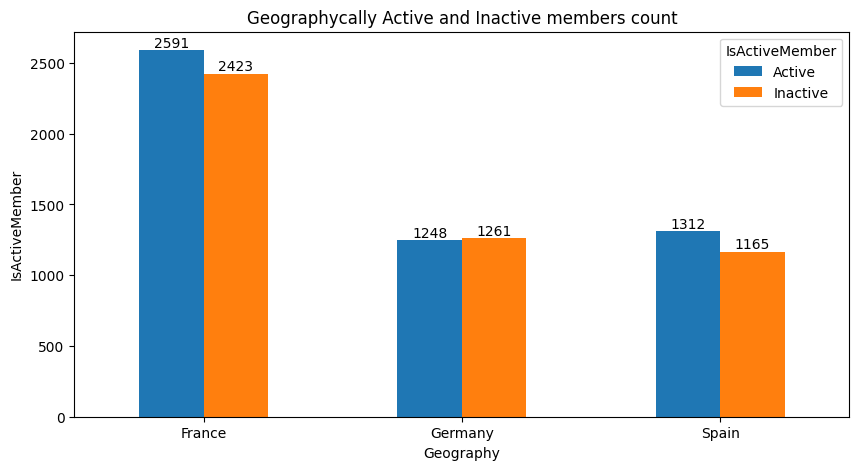

In [18]:
grouped = pd.crosstab(data['Geography'],data['IsActiveMember'])

ax = grouped.plot(kind='bar', figsize=(10,5) )
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.xlabel('Geography')
plt.ylabel('IsActiveMember')
plt.title('Geographycally Active and Inactive members count')
plt.xticks(rotation=0)
plt.show()

In [19]:
data_proportion= data['Gender'].value_counts(normalize=True)*100
data_proportion

,proportion
Gender,
Male,54.57
Female,45.43


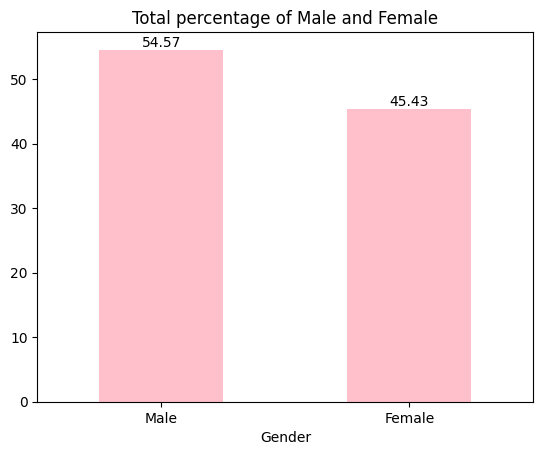

In [20]:
ax = data_proportion.plot.bar(color='pink')
ax.bar_label(ax.containers[0])
plt.xticks(rotation=0)
plt.title('Total percentage of Male and Female')
plt.show()

In [21]:
grouped=round(data.groupby('Gender')['Exited'].value_counts(normalize=True)*100,2)

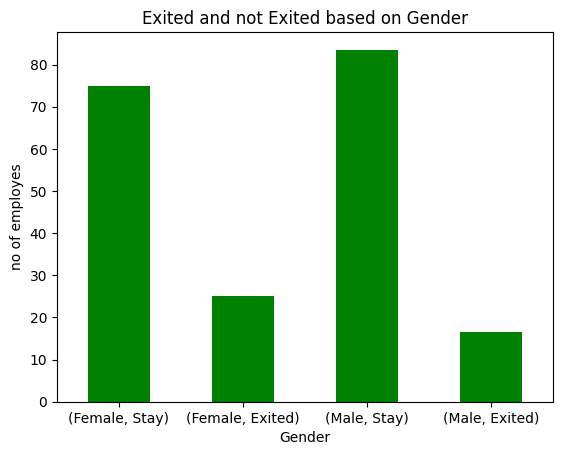

In [22]:
grouped.plot(kind='bar', color = 'Green')
plt.title('Exited and not Exited based on Gender')
plt.xlabel('Gender')
plt.ylabel('no of employes')
plt.xticks(rotation=0)
plt.show()


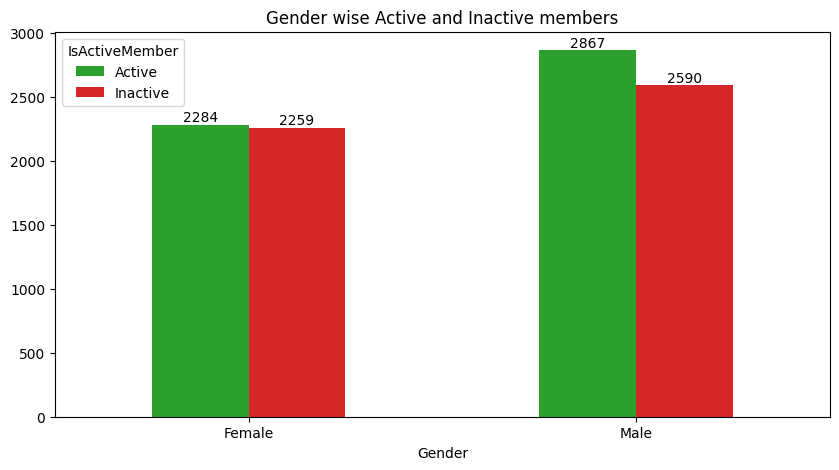

In [23]:
grouped = pd.crosstab(data['Gender'],data['IsActiveMember'])

ax = grouped.plot(kind='bar', figsize = (10,5), color=['#2ca02c', '#d62728'])
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Gender wise Active and Inactive members')
plt.xticks(rotation=0)
plt.show()

In [24]:
#maximum and minimum credit score
print("max credit score", data['CreditScore'].max())
print("min credit score", data['CreditScore'].min())

max credit score 850
min credit score 350


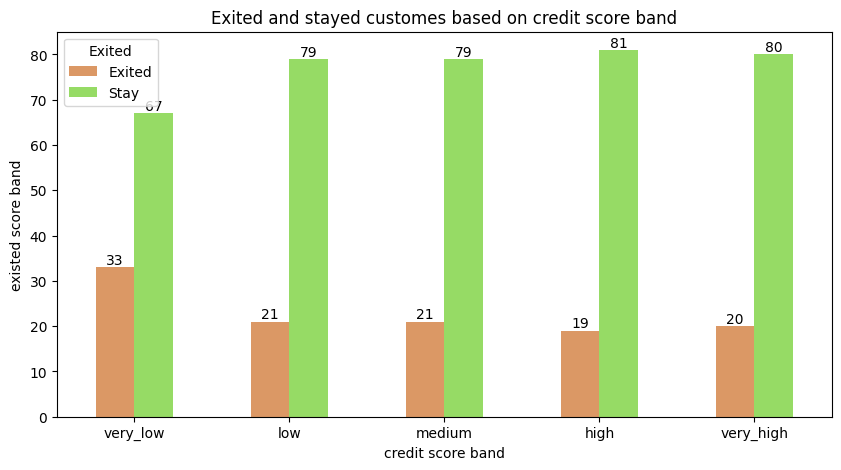

In [25]:
#creating credit score band and assigning it to bins
bins = [300,450,550,650,750,850]
labels = ['very_low','low','medium','high','very_high']

data['credit_score_band'] = pd.cut(data['CreditScore'],
bins = bins,
labels = labels,
right = False,
include_lowest = True)

grouped_credit_score = round(data.groupby('credit_score_band')['Exited'].value_counts(normalize=True)*100).unstack()
grouped_credit_score
ax = grouped_credit_score.plot(kind ='bar', figsize = (10,5), color =['#db9865','#96db65'])
plt.title('Exited and stayed customes based on credit score band')
plt.xlabel('credit score band')
plt.ylabel('existed score band')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.xticks(rotation=0)
plt.show()



In [26]:
#customer churn based on balance
exit_propo_on_balance =round(data.groupby('Balance')['Exited'].value_counts(normalize=True)*100)
exit_propo_on_balance

Balance    Exited
0.00       Stay       86.0
           Exited     14.0
3768.69    Exited    100.0
12459.19   Exited    100.0
14262.80   Stay      100.0
                     ...  
216109.88  Exited    100.0
221532.80  Stay      100.0
222267.63  Exited    100.0
238387.56  Exited    100.0
250898.09  Exited    100.0
Name: proportion, Length: 6384, dtype: float64

In [27]:
#customer churn based on estimated salary
grouped_credit_score = round(data.groupby('credit_score_band')['Exited'].value_counts(normalize=True)*100)
grouped_credit_score

credit_score_band  Exited
very_low           Stay      67.0
                   Exited    33.0
low                Stay      79.0
                   Exited    21.0
medium             Stay      79.0
                   Exited    21.0
high               Stay      81.0
                   Exited    19.0
very_high          Stay      80.0
                   Exited    20.0
Name: proportion, dtype: float64

383.0
919.0


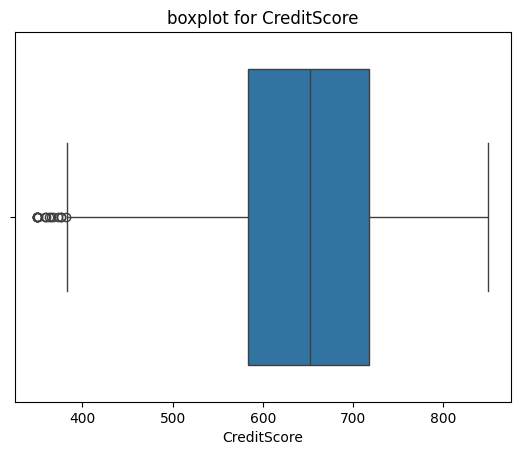

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,credit_score_band,treated_credit_score
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,Active,101348.88,Exited,medium,619.0
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,Active,112542.58,Stay,medium,608.0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,Inactive,113931.57,Exited,low,502.0
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,Inactive,93826.63,Stay,high,699.0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,Active,79084.10,Stay,NaN,850.0


In [28]:
#box plot for exit and not exited customers

q1 = data['CreditScore'].quantile(0.25)
q3 = data['CreditScore'].quantile(0.75)

iqr = q3-q1

lower_fence = q1 - (1.5)*iqr
upper_fence = q3 + (1.5)*iqr

print(lower_fence)
print(upper_fence)

sns.boxplot(x=data['CreditScore'])
plt.title('boxplot for CreditScore')
plt.show()

data['treated_credit_score'] = data['CreditScore']

data['treated_credit_score'] = np.where(data['treated_credit_score']<lower_fence, lower_fence, data['treated_credit_score'])
data['treated_credit_score'] = np.where(data['treated_credit_score']>upper_fence, upper_fence, data['treated_credit_score'])


data.head()

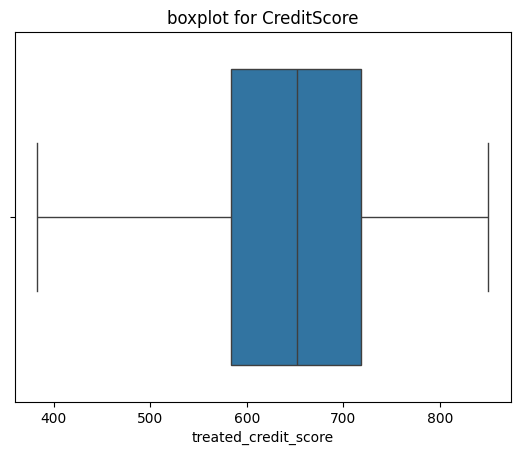

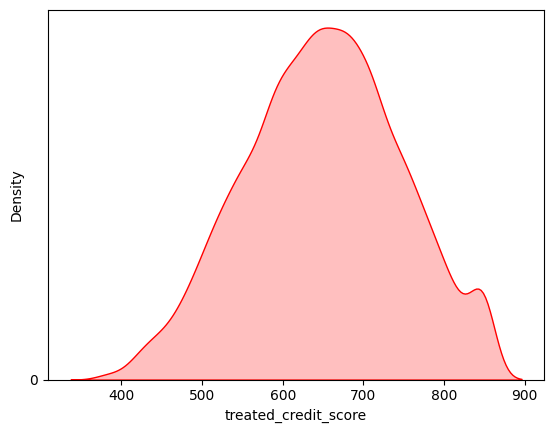

In [29]:
#data sample for treated values

data[data['CreditScore'] < lower_fence][['CreditScore', 'treated_credit_score']]

sns.boxplot(x=data['treated_credit_score'])
plt.title('boxplot for CreditScore')
plt.show()

sns.kdeplot(data['treated_credit_score'], color='red', fill=True)
plt.yticks([0])
plt.xticks()
plt.show()

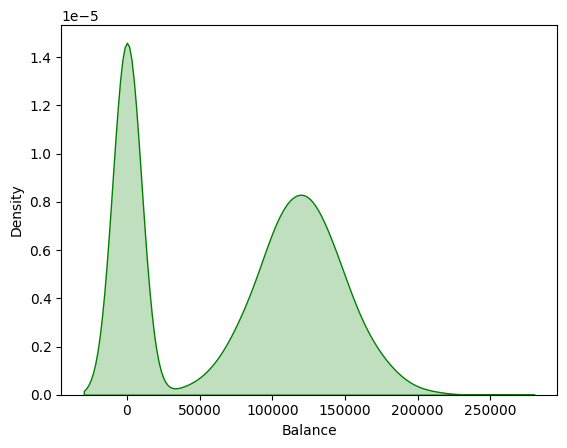

Mean:  76485.89
Std:  62397.41


In [30]:

balance = data['Balance'].dropna()

sns.kdeplot(data['Balance'],color='green', fill=True)
plt.show()

print('Mean: ',round(data['Balance'].mean(),2))
print('Std: ',round(data['Balance'].std(),2))

In [31]:
# convert normal distribution to standard normal distribution

# lets scale Balance
scale = StandardScaler()

# storing the object in a variable
scaled_balance = scale.fit_transform(data[['Balance']])

# stats
print('Mean: ',round(np.mean(scaled_balance),2))
print('Std: ',round(np.std(scaled_balance),2))


Mean:  -0.0
Std:  1.0


In [32]:
# transformed array
scaled_balance

array([[-1.22584767],
       [ 0.11735002],
       [ 1.33305335],
       ...,
       [-1.22584767],
       [-0.02260751],
       [ 0.85996499]])

In [33]:
# stats summary of the data before standardizing
data.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,EstimatedSalary,treated_credit_score
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,100090.239881,650.561300
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,57510.492818,96.558702
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,11.580000,383.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,51002.110000,584.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,100193.915000,652.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,149388.247500,718.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,199992.480000,850.000000


In [34]:
# covert the transformed array to dataframe
scaled_balance_df = pd.DataFrame(scaled_balance, columns=scale.get_feature_names_out(['Balance']))

scaled_balance_df

,Balance
0,-1.225848
1,0.117350
2,1.333053
3,-1.225848
4,0.785728
...,...
9995,-1.225848
9996,-0.306379
9997,-1.225848
9998,-0.022608


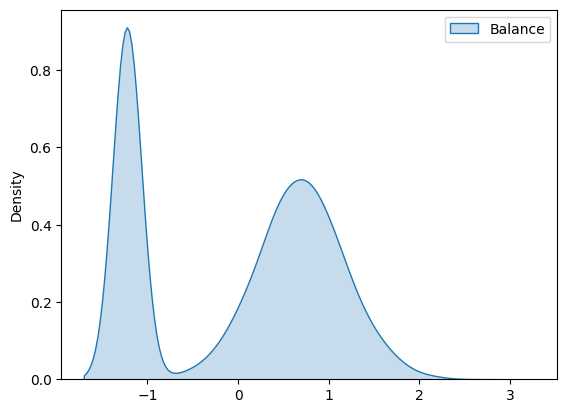

Mean:  Balance   -0.0
dtype: float64
std:  Balance    1.0
dtype: float64


In [35]:
# Distribution and values of 'balance' after standardisation
sns.kdeplot(scaled_balance_df, color = 'purple', fill=True)
plt.show()

print('Mean: ', round(scaled_balance_df.mean(),2))
print('std: ', round(scaled_balance_df.std(),2))